# BANANA

### IMPORT

In [1]:
import os, sys, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from arch import arch_model

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath('../scripts'))

from spread import SPREAD
from screener import SCREENER
from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET

### PARAMS

In [2]:
TRAIN_DAYS = 30
COINT_WINDOW = 300          # Keep: Captures the short-term microstructure beta
Z_WINDOW = 100              # Keep: Fast rolling mean to fade bid/ask bounces

ENTRY_Z = 1.50              # TWEAKED: Raised from 1.25
EXIT_Z = -0.25              # Keep: Captures momentum past the mean
AR_LIMIT = 0.985            # TWEAKED: Tightened from 0.995
DANGER_THRESHOLD = 0.95     # TWEAKED: Raised from 0.90

### DATA

In [3]:
months = [
    "202401", "202402", "202403", "202404", "202405", "202406",
    "202407", "202408", "202409", "202410", "202411", "202412",
    "202501", "202502", "202503", "202504", "202505", "202506",
    "202507", "202508", "202509", "202510", "202511", "202512"
]

my_files = [
    [f"../data/processed/eurnok_dukascopy_ask_{m}.parquet" for m in months],
    [f"../data/processed/eurnok_dukascopy_bid_{m}.parquet" for m in months],
    [f"../data/processed/eursek_dukascopy_ask_{m}.parquet" for m in months],
    [f"../data/processed/eursek_dukascopy_bid_{m}.parquet" for m in months],
]

### SPREAD

built 28661 rows
                                    Asset_A     Bid_A     Ask_A   Asset_B  \
timestamp                                                                   
2024-01-02 10:09:39.568000+00:00  11.212115  11.21050  11.21373  11.10231   
2024-01-02 10:11:36.626000+00:00  11.218585  11.21621  11.22096  11.10231   
2024-01-02 10:14:59.375000+00:00  11.235295  11.23395  11.23664  11.10640   

                                     Bid_B     Ask_B     Log_A     Log_B  \
timestamp                                                                  
2024-01-02 10:09:39.568000+00:00  11.10107  11.10355  2.416995  2.407153   
2024-01-02 10:11:36.626000+00:00  11.10107  11.10355  2.417572  2.407153   
2024-01-02 10:14:59.375000+00:00  11.10526  11.10754  2.419060  2.407522   

                                  Return_A  Return_B  HalfSpread_A_bps  \
timestamp                                                                
2024-01-02 10:09:39.568000+00:00  0.000288  0.000000          1.4404

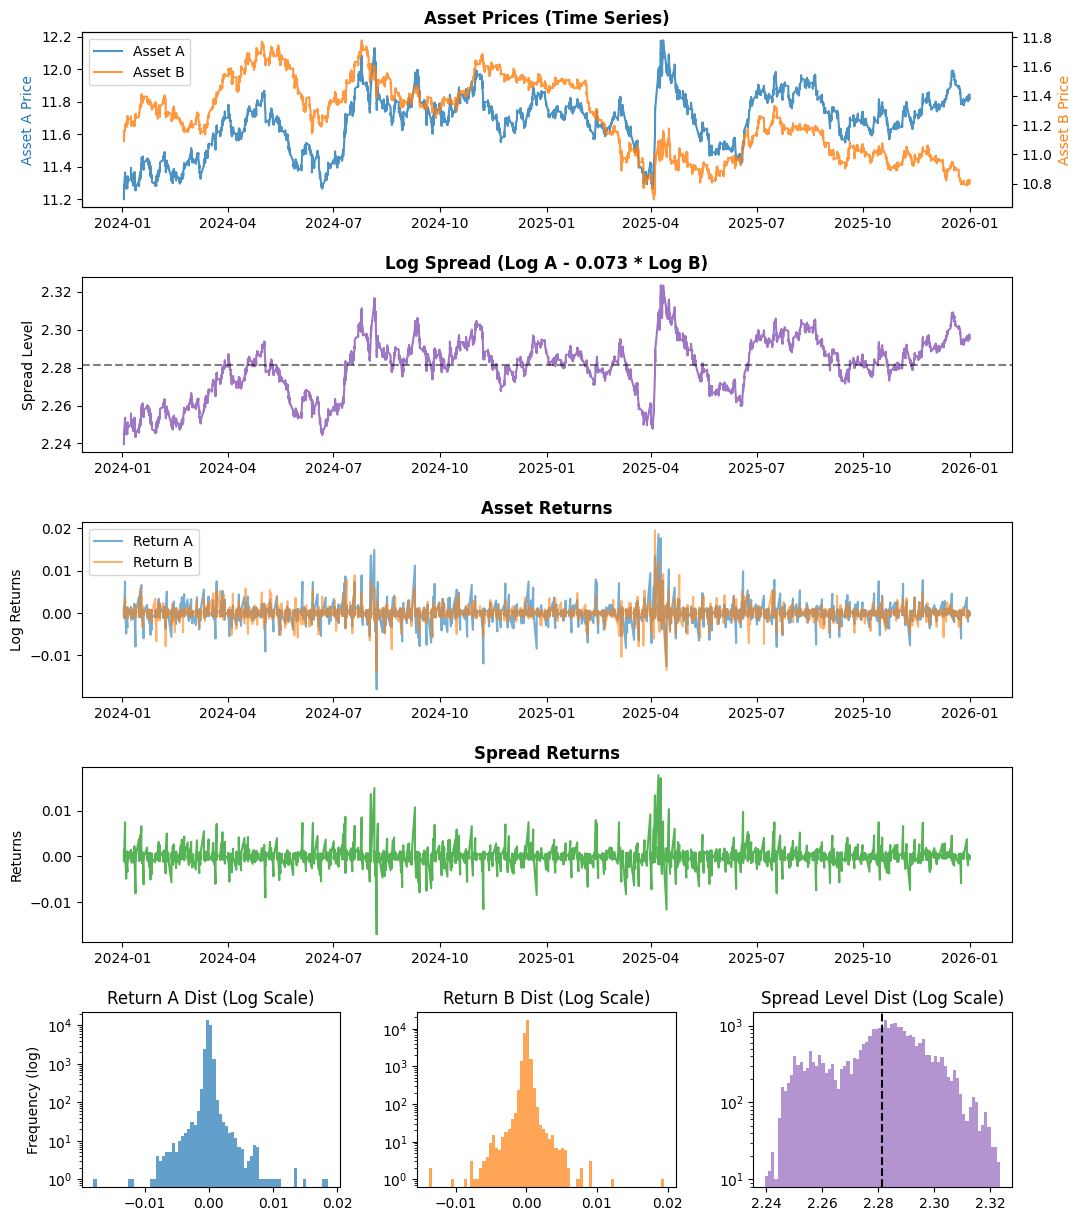

In [4]:
builder = SPREAD(agg_type='volume', threshold=1000, active_hours=(10, 14))
df = builder.build(my_files)

print(df.head(3))
print("\nColumns:", list(df.columns))
print(f"Median half-spread (bps) — A: {df['HalfSpread_A_bps'].median():.2f} | "
      f"B: {df['HalfSpread_B_bps'].median():.2f}")

# Call the new diagnostic plotter after the data is built
builder.plot_diagnostics()

### SCREENER


=== COINTEGRATION SCREENER ===
Full: p=0.0224 | half-life=818.9 | β=0.0732

Rolling (2000-bar, step 200, n=134):
  p<0.05: 9.7% | p<0.10: 17.9%
  half-life: 99.5 (IQR 69–187)
  β: 0.7508 ±0.5993 [-1.1818, 2.3368]


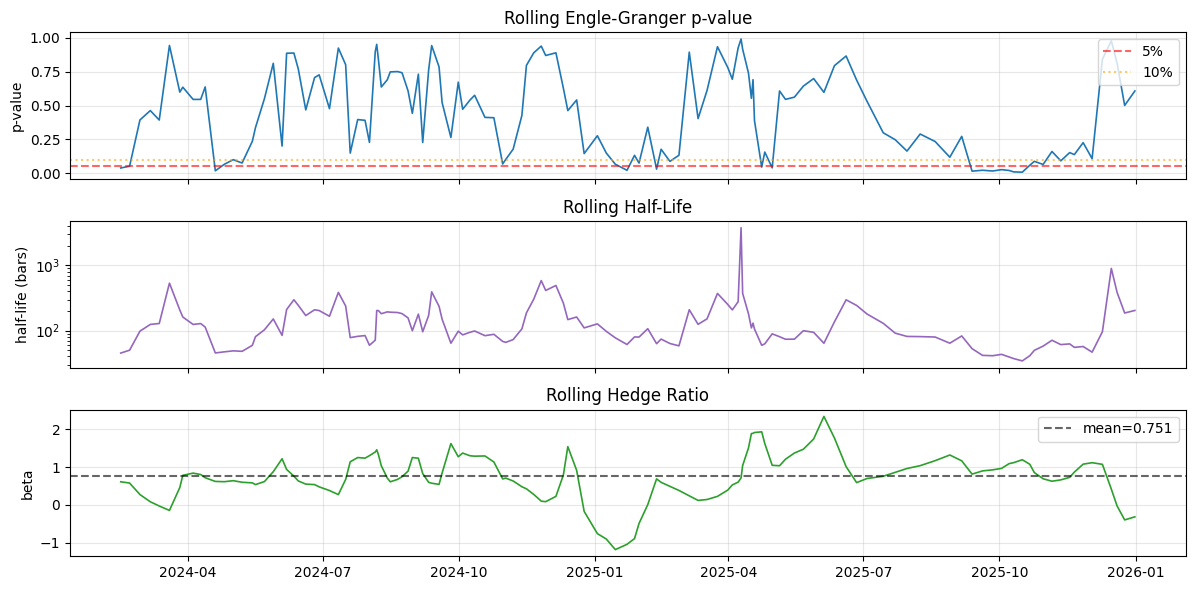

In [5]:
screener = SCREENER(df['Asset_A'], df['Asset_B'])
p_val, hl = screener.generate_report(rolling_window=2000, rolling_step=200)

### MORE IMPORTS

In [6]:
import importlib
import engine, backtester, tearsheet
importlib.reload(engine)
importlib.reload(backtester)
importlib.reload(tearsheet)

from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET

In [7]:
live_trading_data, df_params = ENGINE.walk_forward(
    df=df, 
    train_days=TRAIN_DAYS, 
    coint_window=COINT_WINDOW, 
    z_window=Z_WINDOW
)

Running Engine | train_days=30 | coint_window=300 | z_window=100
[2024-02-13] Beta: 0.7787 | AR: 0.9760
[2024-02-27] Beta: -0.7395 | AR: 0.9821
[2024-03-12] Beta: 0.8673 | AR: 0.9873
[2024-03-26] Beta: 0.5417 | AR: 0.9887
[2024-04-09] Beta: 1.0556 | AR: 0.9810
[2024-04-23] Beta: 0.9725 | AR: 0.9764
[2024-05-07] Beta: 1.1872 | AR: 0.9821
[2024-05-21] Beta: 0.5658 | AR: 0.9833
[2024-06-04] Beta: 0.2429 | AR: 0.9767
[2024-06-18] Beta: 0.4969 | AR: 0.9807
[2024-07-02] Beta: 0.6004 | AR: 0.9863
[2024-07-16] Beta: 0.9200 | AR: 0.9854
[2024-07-30] Beta: 0.9857 | AR: 0.9826
[2024-08-13] Beta: -0.5734 | AR: 0.9869
[2024-08-27] Beta: 1.5860 | AR: 0.9878
[2024-09-10] Beta: 1.8418 | AR: 0.9871
[2024-09-24] Beta: 0.2833 | AR: 0.9801
[2024-10-08] Beta: 0.4019 | AR: 0.9821
[2024-10-22] Beta: 0.6724 | AR: 0.9839
[2024-11-05] Beta: 1.0270 | AR: 0.9745
[2024-11-19] Beta: -0.0333 | AR: 0.9784
[2024-12-03] Beta: 0.8546 | AR: 0.9867
[2024-12-17] Beta: 0.1301 | AR: 0.9891
[2025-01-02] Beta: 0.3581 | AR: 0.9

In [8]:
bt = BACKTESTER(live_trading_data)
results_df = bt.run(
    base_z=ENTRY_Z,
    exit_z=EXIT_Z,
    danger_threshold=DANGER_THRESHOLD,   
    ar_limit=AR_LIMIT,
    fee_bps=0.5,
    slippage_mode='half_spread'
)


                      QUANTITATIVE STRATEGY TEARSHEET                      
Metric                         | Baseline     | AR           | MS_AR        |
-----------------------------------------------------------------------------

--- FINANCIAL METRICS ---
Total Return (bps)             | -168.18      | -1031.02     | -1222.41     |
Annual Return (bps)            | -86.67       | -531.32      | -629.95      |
Annual Volatility (bps)        | 718.57       | 556.02       | 539.19       |
Max Drawdown (bps)             | -1026.49     | -1735.25     | -1752.69     |
Sharpe Ratio                   | -0.12        | -0.96        | -1.17        |
Sortino Ratio                  | -0.12        | -0.69        | -0.83        |
Calmar Ratio                   | 0.08         | 0.31         | 0.36         |
Gross Profit (bps)             | 34891.18     | 19584.22     | 18891.49     |
Gross Loss (bps)               | 35059.36     | 20615.24     | 20113.90     |
Profit Factor                  | 1.00 

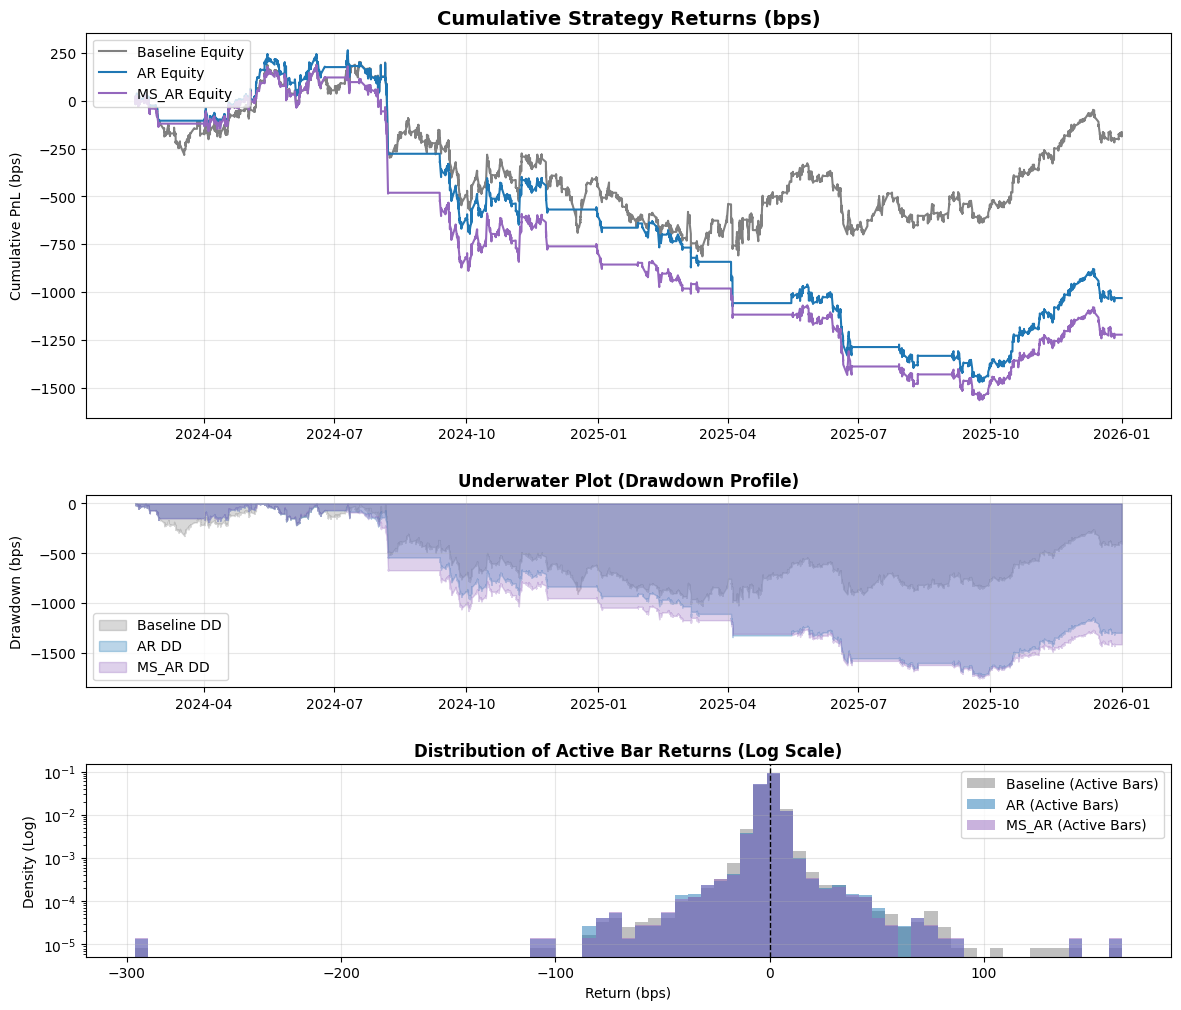

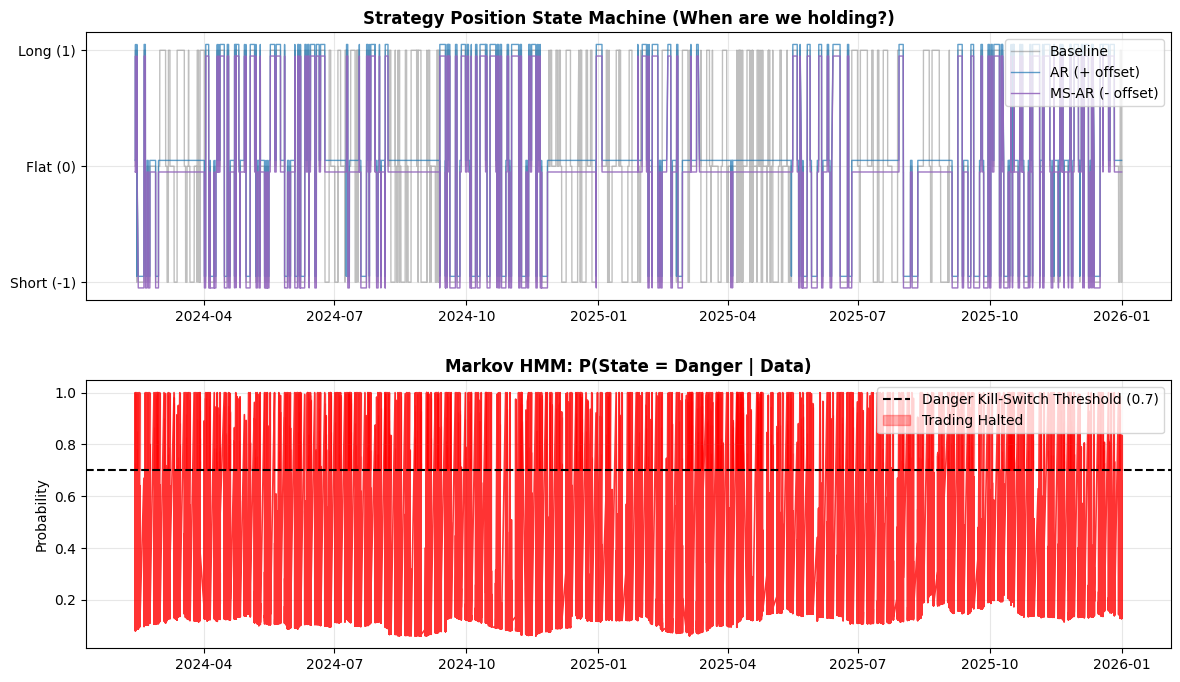

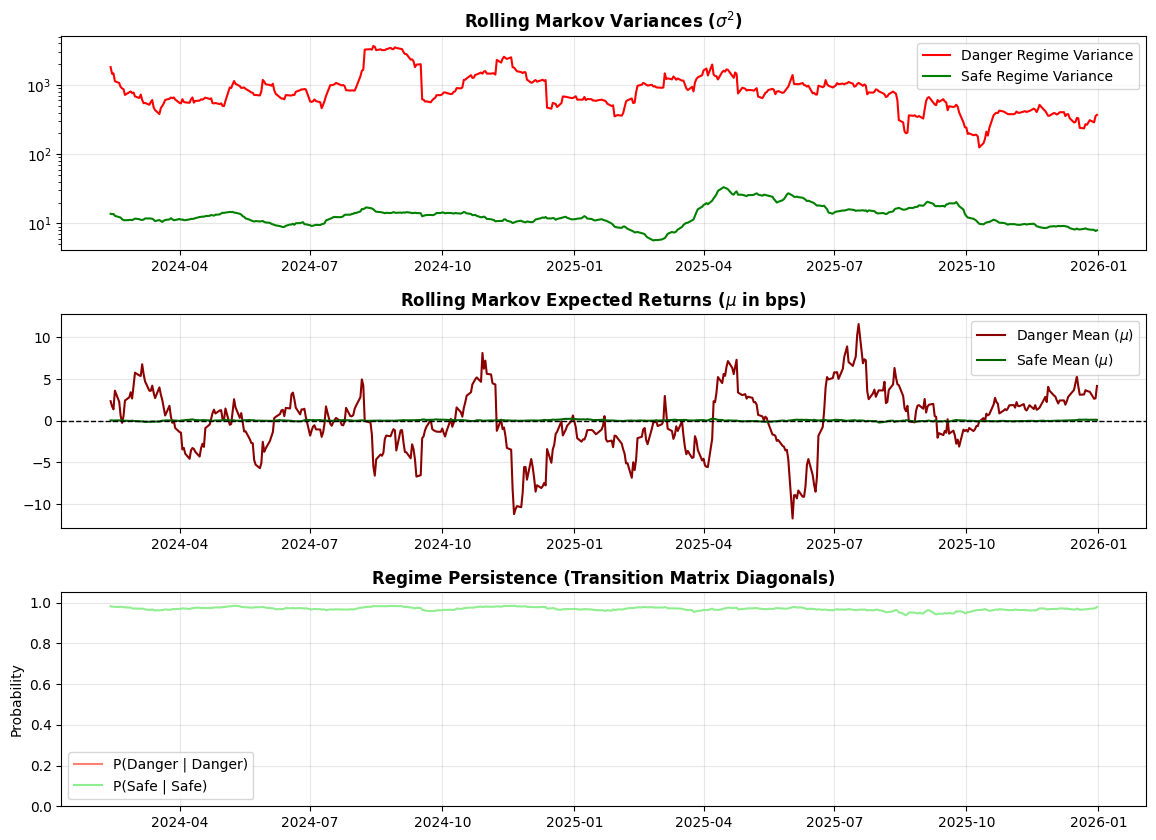

In [9]:
ts = TEARSHEET(results_df, df_params=df_params)
ts.generate_report()
ts.plot_performance()
ts.plot_positions_and_regimes()
ts.plot_markov_dynamics()